# __Master Pipeline__

# **0. Librairies**

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
from sklearn.metrics import confusion_matrix


sys.path.append(os.path.abspath(".."))

from lib.data.dataset import BeeDataset
from lib.data.preprocessing import TorchPreprocessor
from lib.data.train_val_split import train_val_split
from lib.data.preprocessing import TorchPreprocessor
from lib.data.data_augmentation import data_augmented_loader, final_training_data_loader
from lib.utils.model_saver import ModelSaver

In [28]:
## CONFIGURATION
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 64
NUM_EPOCHS = 25
LR = 0.01

DROPOUT = 0.4
WEIGHT_DECAY = 1e-4

USER_NAME = 'Maignan'

NUM_CLASSES = 50

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

### **Booléen par block**

In [29]:
scheduler = True
focal_loss = True
wheigted = False
unfreeze = True
data_augmentation = True
data_differntiation = True

convnext = True

validation = True

## **1. Preprocessing**

In [30]:
resnet_processor_parameters = {
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    "crop_size": (224, 224)
}

if convnext:
    resize_value = 230
else :
    resize_value = 256

train_preprocessor_light = TorchPreprocessor (mean = resnet_processor_parameters["mean"], 
                                              std = resnet_processor_parameters["std"], 
                                              normalize = True,
                                              augmentation = 'light', 
                                              resize_method = 'pad', 
                                              resize_value = resize_value, 
                                              target_size = (224,224)) 

train_preprocessor_heavy = TorchPreprocessor (mean = resnet_processor_parameters["mean"], 
                                              std = resnet_processor_parameters["std"], 
                                              normalize = True,
                                              augmentation = 'heavy', 
                                              resize_method = 'pad', 
                                              resize_value = resize_value, 
                                              target_size = (224,224)) 


val_preprocessor = TorchPreprocessor (mean = resnet_processor_parameters["mean"], 
                                      std = resnet_processor_parameters["std"], 
                                      normalize = True,
                                      augmentation = 'None', 
                                      resize_method = 'pad', 
                                      resize_value = resize_value, 
                                      target_size = (224,224)) 

In [31]:

if data_augmentation:
    train_loader, val_loader = data_augmented_loader(IMAGENET_MEAN, IMAGENET_STD, target_size=(224, 224), batch_size=BATCH_SIZE,  apply_augmentation = data_augmentation)
elif data_augmentation and data_differntiation:
    train_loader, val_loader = data_augmented_loader(IMAGENET_MEAN, IMAGENET_STD, target_size=(224, 224), 
                                                     batch_size=BATCH_SIZE,
                                                     apply_augmentation = data_augmentation, 
                                                     distinguish_classes=data_differntiation,
                                                     train_preprocessor_light = train_preprocessor_light,
                                                     train_preprocessor_heavy = train_preprocessor_heavy,
                                                     val_preprocessor = val_preprocessor)
else:
    train_loader, val_loader = data_augmented_loader(IMAGENET_MEAN, IMAGENET_STD, target_size=(224, 224), batch_size=BATCH_SIZE)

Train prêt : 6417 images (Augmentation UNIFORME, Tirage CLASSIQUE)
Val prête  : 1582 images (sans augmentation)


In [32]:
# --- Récupérer tous les labels du val_loader ---
all_labels = []

for _, labels in val_loader:
    all_labels.extend(labels.numpy() if isinstance(labels, torch.Tensor) else labels)

# --- Compter le nombre d'images par classe ---
class_counts_val = pd.Series(all_labels).value_counts().sort_index()

# --- Créer un DataFrame ---
df_val_counts = pd.DataFrame({
    "class": class_counts_val.index,
    "num_images": class_counts_val.values
})

# --- Sauvegarder dans un CSV ---
csv_val_path = "val_class_counts.csv"
df_val_counts.to_csv(csv_val_path, index=False)
print(f"CSV des images par classe dans la validation sauvegardé dans : {csv_val_path}")

CSV des images par classe dans la validation sauvegardé dans : val_class_counts.csv


## **2. Modèle**

In [33]:
val_class_counts = pd.read_csv("val_class_counts.csv")
weights = 1.0 / val_class_counts["num_images"].values

In [34]:
class ResnetFineTune (nn.Module):
    def __init__(self, num_classes, 
                 dropout, 
                 freeze = False,
                 unfreeze = False):
        
        super(ResnetFineTune, self).__init__()

        self.resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        
        if freeze:
            for param in self.resnet.parameters():
                param.requires_grad = False

            for param in self.resnet.layer4.parameters():
                param.requires_grad = True
                
        if unfreeze:
            for param in self.resnet.parameters():
                param.requires_grad = False

        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )

    def forward (self, x):
        return self.resnet(x)
    
    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1).item()
        
        return pred_class

In [35]:
import torch
import torch.nn as nn
from torchvision import models

class ConvNeXtFineTune(nn.Module):
    def __init__(self, num_classes, dropout=0.3, freeze=False, unfreeze=False):
        super().__init__()

        self.backbone = models.convnext_small(weights=models.ConvNeXt_Small_Weights.IMAGENET1K_V1)

        if freeze:
            for param in self.backbone.parameters():
                param.requires_grad = False

            for param in self.backbone.features[-1].parameters():
                param.requires_grad = True

        if unfreeze:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.classifier[2].in_features  
        self.backbone.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1).item()
        return pred_class

In [36]:
if convnext:
    model = ConvNeXtFineTune(NUM_CLASSES, DROPOUT, freeze = False, unfreeze = unfreeze)
else:
    model = ResnetFineTune(NUM_CLASSES, DROPOUT, freeze = False, unfreeze = unfreeze)
model.to(DEVICE)

ConvNeXtFineTune(
  (backbone): ConvNeXt(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            if not isinstance(alpha, torch.Tensor):
                alpha = torch.tensor(alpha, dtype=torch.float32)
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss).clamp(min=1e-8, max=1.0)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha = self.alpha.to(targets.device) 
            alpha = alpha[targets]
            focal_loss = alpha * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [38]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

train_labels = np.load('train_labels.npy')


def compute_alpha(train_labels, num_classes):
    classes = np.arange(num_classes)
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=train_labels
    )
    # Normaliser entre 0 et 1
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights, dtype=torch.float32)



In [39]:

if focal_loss:

    alpha = compute_alpha(train_labels, num_classes=50)
    criterion = FocalLoss(gamma=2.0, alpha=None)

elif wheigted:
    val_class_counts = pd.read_csv("val_class_counts.csv")
    weights = 1.0 / np.sqrt(val_class_counts["num_images"].values)


    criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE))
else:
    criterion = nn.CrossEntropyLoss()

In [40]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

In [41]:
ModelSaver = ModelSaver(model=model, username=USER_NAME)
ModelSaver.save_training_config(model, optimizer, BATCH_SIZE, NUM_EPOCHS, LR, DROPOUT, DEVICE, criterion=criterion)

In [42]:
if scheduler:
    # Usage de OneCycleLR
    steps_per_epoch = len(train_loader)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=LR,
        steps_per_epoch=steps_per_epoch,
        epochs=NUM_EPOCHS,
        pct_start=0.1, # 10% du temps d'entraînement sera dédié au Warm-up (montée douce du LR)
        div_factor=10.0, # Le LR commence à LR / 10
        final_div_factor=30.0 # Le LR finit très bas
    )

In [43]:
def unfreeze_progressive(model, epoch):
    if convnext:
        # Dégeler progressivement les stages
        stages = model.backbone.features  # 4 stages + stem
        if epoch == 1:
            for param in stages[-1].parameters():
                param.requires_grad = True
        if epoch == 5:
            for param in stages[-2].parameters():
                param.requires_grad = True
        # if epoch == 10:
        #     for param in stages.parameters():
        #         param.requires_grad = True

    else:
        if epoch == 1:
            print("Unfreezing layer4")
            for param in model.resnet.layer4.parameters():
                param.requires_grad = True

        if epoch == 5:
            print("Unfreezing layer3")
            for param in model.resnet.layer3.parameters():
                param.requires_grad = True

        # if epoch == 10:
        #     print("Unfreezing full backbone")
        #     for param in model.resnet.parameters():
        #         param.requires_grad = True

## **3. F1-score**

In [44]:
import numpy as np

def compute_f1(all_labels, all_preds, num_classes):
    f1_per_class = []

    for cls in range(num_classes):
        # True Positives
        TP = np.sum((np.array(all_preds) == cls) & (np.array(all_labels) == cls))
        # False Positives
        FP = np.sum((np.array(all_preds) == cls) & (np.array(all_labels) != cls))
        # False Negatives
        FN = np.sum((np.array(all_preds) != cls) & (np.array(all_labels) == cls))

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0

        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_per_class.append(f1)

    # F1 macro : moyenne des classes
    f1_macro = np.mean(f1_per_class)
    return f1_macro, f1_per_class

In [45]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

def compute_all_metrics(all_labels, all_preds, num_classes):
    """
    Calcule toutes les métriques en utilisant ta fonction compute_f1 personnalisée.
    """
    all_preds_np = np.array(all_preds)
    all_labels_np = np.array(all_labels)
    acc = np.mean(all_preds_np == all_labels_np)

    f1_macro, f1_per_class = compute_f1(all_labels, all_preds, num_classes)

    precision_per_class = precision_score(all_labels, all_preds, average=None, labels=range(num_classes), zero_division=0)
    recall_per_class = recall_score(all_labels, all_preds, average=None, labels=range(num_classes), zero_division=0)

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_per_class": f1_per_class,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class
    }

In [46]:
def compute_confusion_matrix(model, data_loader, device="cpu", num_classes=None):
    model.to(device)
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    if num_classes is None:
        num_classes = max(max(all_labels), max(all_preds)) + 1

    cm = confusion_matrix(all_labels, all_preds)
    return cm

## **4. Fonctions de training et validation**

In [47]:
def train_one_epoch(epoch):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # 🔹 Calcul F1 avec ta fonction existante
    all_metrics = compute_all_metrics(all_labels, all_preds, NUM_CLASSES)
    ModelSaver.save_epoch(epoch, all_metrics, total_loss / len(train_loader), mode="train")

    f1_macro = all_metrics["f1_macro"]
    f1_per_class = all_metrics["f1_per_class"]

    # 🔹 Affichage
    print(f"Train F1 macro: {f1_macro:.4f}")

    return total_loss / len(train_loader), correct / total, f1_macro, f1_per_class


In [48]:
import torch

def validate(epoch):
    model.eval()
    total_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calcul F1 manuel par classe
    all_metrics = compute_all_metrics(all_labels, all_preds, NUM_CLASSES)
    ModelSaver.save_epoch(epoch, all_metrics, total_loss / len(val_loader), mode="val")

    f1_macro = all_metrics["f1_macro"]
    f1_per_class = all_metrics["f1_per_class"]

    return (total_loss / len(val_loader), f1_macro, f1_per_class, np.array(all_preds), np.array(all_labels))

## **5. Entrainement**

**Entrainement**

In [ ]:
import csv
import pandas as pd
from sklearn.metrics import confusion_matrix

best_f1 = 0.0

csv_file = "training_log.csv"
fieldnames = ['epoch', 'train_loss', 'train_acc', 'train_f1_macro',
              'val_loss', 'val_f1_macro']


loss_train, loss_val = [], []

for epoch in range(NUM_EPOCHS):

    # ===== TRAIN =====
    train_loss, train_acc, train_f1_macro, train_f1_per_class = train_one_epoch(epoch)
    loss_train.append(train_loss)

    if scheduler:
        scheduler.step()

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Train F1 Macro: {train_f1_macro:.4f}")

    if unfreeze:
        unfreeze_progressive(model, epoch)

    if validation:
        # ===== VALIDATION =====
        val_loss, val_f1_macro, val_f1_per_class, val_preds, val_labels = validate(epoch)
        loss_val.append(val_loss)
        
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Val F1 Macro: {val_f1_macro:.4f}")




        # ===== BEST MODEL =====
        if val_f1_macro > best_f1:
            best_f1 = val_f1_macro

            ModelSaver.save_model(model, name=f"best_model_epoch_{epoch}.pth")

            cm = compute_confusion_matrix(model, val_loader, device=DEVICE, num_classes=NUM_CLASSES)
            ModelSaver.save_confusion_matrix(cm, name=f"confusion_matrix_epoch_{epoch}.csv")        

            print(f" Nouveau meilleur modèle sauvegardé ! F1 Macro = {best_f1:.4f}")


       

100%|██████████| 101/101 [01:50<00:00,  1.09s/it]


Train F1 macro: 0.0291

Epoch 1/25
Train Loss: 2.8366 | Train Acc: 0.1661
Train F1 Macro: 0.0291
Val Loss: 2.5316
Val F1 Macro: 0.0422
 Nouveau meilleur modèle sauvegardé ! F1 Macro = 0.0422


100%|██████████| 101/101 [00:46<00:00,  2.15it/s]


Train F1 macro: 0.0577

Epoch 2/25
Train Loss: 2.4593 | Train Acc: 0.2741
Train F1 Macro: 0.0577
Val Loss: 2.3517
Val F1 Macro: 0.0619
 Nouveau meilleur modèle sauvegardé ! F1 Macro = 0.0619


100%|██████████| 101/101 [00:56<00:00,  1.78it/s]


...

Train F1 macro: 0.4097

Epoch 7/25
Train Loss: 0.9027 | Train Acc: 0.6247
Train F1 Macro: 0.4097
Val Loss: 0.6690
Val F1 Macro: 0.4080
 Nouveau meilleur modèle sauvegardé ! F1 Macro = 0.4080


100%|██████████| 101/101 [00:43<00:00,  2.33it/s]


Train F1 macro: 0.4843

Epoch 8/25
Train Loss: 0.7193 | Train Acc: 0.6843
Train F1 Macro: 0.4843
Val Loss: 0.6498
Val F1 Macro: 0.4749
 Nouveau meilleur modèle sauvegardé ! F1 Macro = 0.4749


100%|██████████| 101/101 [00:46<00:00,  2.15it/s]


Train F1 macro: 0.5813

Epoch 9/25
Train Loss: 0.6257 | Train Acc: 0.7172
Train F1 Macro: 0.5813
Val Loss: 0.5991
Val F1 Macro: 0.4913


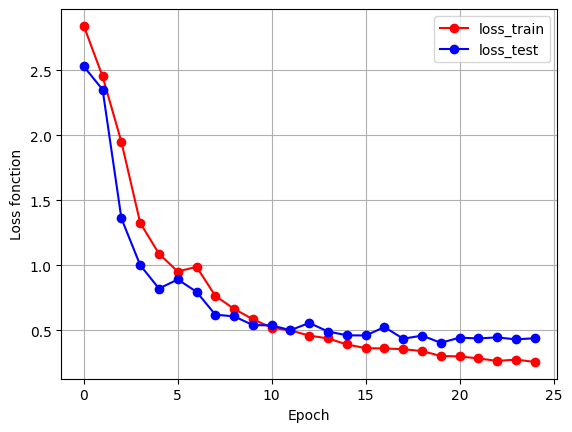

In [ ]:
plt.plot(loss_train, 'r' , marker='o', linestyle='-', label = 'loss_train')
plt.plot(loss_val, 'b' , marker='o', linestyle='-', label = 'loss_test')
plt.xlabel('Epoch')
plt.ylabel('Loss fonction')
plt.grid()
plt.legend()
plt.show()

In [ ]:
# model = ConvNeXtFineTune(NUM_CLASSES, DROPOUT, freeze = False, unfreeze = unfreeze)

# checkpoint = torch.load(
#     "../results/ConvNeXtFineTune_Maignan_10h32/best_model_epoch_18.pth",
#     map_location=DEVICE
# )

# model.load_state_dict(checkpoint)
# model.to(DEVICE)
# model.eval()

ConvNeXtFineTune(
  (backbone): ConvNeXt(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm

In [ ]:
def submission(model, X_test):
    pred = []
    for img in X_test:

        img = img[0].unsqueeze(0).to(DEVICE)  
        pred.append(model.to(DEVICE).inference(img))

    df = pd.DataFrame({
        "id": range(len(pred)),
        "label": pred
    })

    df.to_csv("submission3.csv", index=False)

# **8. Fine tuning**


In [ ]:
train_loader = final_training_data_loader(IMAGENET_MEAN, IMAGENET_STD, target_size=(224, 224), 
                                                batch_size=BATCH_SIZE, 
                                                apply_augmentation = data_augmentation, 
                                                distinguish_classes=data_differntiation, 
                                                train_preprocessor_light = train_preprocessor_light, 
                                                train_preprocessor_heavy = train_preprocessor_heavy)


NUM_EPOCHS_fin_tune = 5

Path_model = "../results/ConvNeXtFineTune_Maignan_10h32/best_model_epoch_18.pth"

In [ ]:
model = ConvNeXtFineTune(NUM_CLASSES, DROPOUT, freeze = False, unfreeze = unfreeze)

checkpoint = torch.load(
    Path_model,
    map_location=DEVICE
)

model.load_state_dict(checkpoint)
model.to(DEVICE)
model.eval()

In [ ]:
import csv
import pandas as pd
from sklearn.metrics import confusion_matrix


loss_train = []

for epoch in range(NUM_EPOCHS_fin_tune):

    # ===== TRAIN =====
    train_loss, train_acc, train_f1_macro, train_f1_per_class = train_one_epoch(epoch)
    loss_train.append(train_loss)

    if scheduler:
        scheduler.step()

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS_fin_tune}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Train F1 Macro: {train_f1_macro:.4f}")


ModelSaver.save_model(model, name=f"best_model_fine_tune.pth")
       

In [ ]:
test_dataset = BeeDataset(train = False, transform = val_preprocessor)
submission(model, test_dataset)

# **9. Explicabilité**

Image shape : (224, 224, 3)
Vraie classe : 0


  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


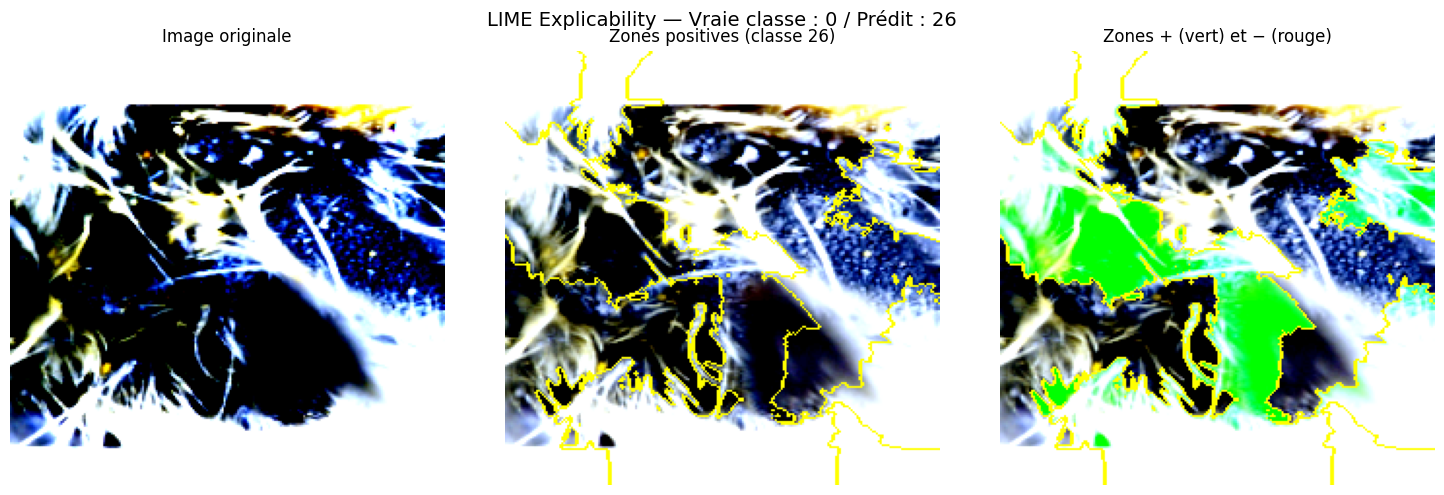

In [ ]:
import numpy as np
import torch
from lime import lime_image
from skimage.segmentation import mark_boundaries


def make_explicability(model, img_tensor, label,  index=0):
    """
    Génère une explication LIME pour une image du dataset.
    
    Args:
        model     : TorchScript model chargé sur GPU
        dataset   : Dataset retournant (image, label)
        index     : Index de l'image à expliquer
    """
    
    # --- 1. Récupération de l'image ---
    # image_tensor, label = dataset[index]  # (C, H, W), label

    # Conversion en numpy (H, W, C) pour LIME
    image_np = img_tensor.permute(1, 2, 0).cpu().numpy().astype(np.float32)

    print(f"Image shape : {image_np.shape}")   # doit être (H, W, 3)
    print(f"Vraie classe : {label}")

    # --- 2. Fonction de prédiction pour LIME ---
    def predict_fn(images_np):
        """
        LIME passe un batch numpy (N, H, W, C) → on retourne (N, num_classes)
        """
        tensor = torch.tensor(images_np, dtype=torch.float32)
        tensor = tensor.permute(0, 3, 1, 2)  # (N, H, W, C) → (N, C, H, W)
        tensor = tensor.to(DEVICE)

        model.eval()
        with torch.no_grad():
            outputs = model(tensor)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()

        return probs  # (N, num_classes)

    # --- 3. Explication LIME ---
    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        image_np,
        predict_fn,
        top_labels=5,
        hide_color=0,
        num_samples=1000,
        batch_size=32
    )

    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)  

    # Image de base
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    fig.suptitle(f"LIME Explicability — Vraie classe : {label} / Prédit : {torch.argmax(model(img_tensor))}", fontsize=14)

    # Image originale
    axes[0].imshow(image_np)
    axes[0].set_title("Image originale")
    axes[0].axis("off")



    # Régions qui contribuent POSITIVEMENT à la prédiction
    top_label = explanation.top_labels[0]
    temp_pos, mask_pos = explanation.get_image_and_mask(
        top_label,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )
    axes[1].imshow(mark_boundaries(temp_pos / 2 + 0.5, mask_pos))
    axes[1].set_title(f"Zones positives (classe {top_label})")
    axes[1].axis("off")

    # Régions positives ET négatives
    temp_both, mask_both = explanation.get_image_and_mask(
        top_label,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )
    axes[2].imshow(mark_boundaries(temp_both / 2 + 0.5, mask_both))
    axes[2].set_title("Zones + (vert) et − (rouge)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return explanation

dataset = train_loader.dataset

make_explicability(model, dataset[0][0], dataset[0][1])

In [ ]:
# import matplotlib.pyplot as plt
# import pandas as pd


 
# # 1. Tes données (extraites de ton image)
# df = pd.read_csv('../models/training_logefficientnetb0_audrey_better_loader_25epoch.csv')
# print(df.head())
# epochs = df['epoch']
# train_loss = df['train_loss']
# val_loss = df['val_loss']
# train_f1 = df['train_f1_macro']
# val_f1 = df['val_f1_macro']


 
# # 2. Création de la figure avec deux sous-graphiques (côte à côte)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


 
# # --- Graphique 1 : La Loss ---
# ax1.plot(epochs, train_loss, label='Train Loss', marker='o', linestyle='--')
# ax1.plot(epochs, val_loss, label='Val Loss', marker='o')
# ax1.set_title('Évolution de la Perte (Loss)')
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('Loss')
# ax1.set_xticks(epochs) # Pour n'afficher que des entiers sur l'axe X
# ax1.legend()
# ax1.grid(True, alpha=0.3)


 
# # --- Graphique 2 : Le F1-Score ---
# ax2.plot(epochs, train_f1, label='Train F1 Macro', marker='s', color='green', linestyle='--')
# ax2.plot(epochs, val_f1, label='Val F1 Macro', marker='s', color='orange')
# ax2.set_title('Évolution du F1-Score Macro')
# ax2.set_xlabel('Epoch')
# ax2.set_ylabel('F1 Score')
# ax2.set_xticks(epochs)
# ax2.legend()
# ax2.grid(True, alpha=0.3)


 
# plt.tight_layout()
# plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../models/training_logefficientnetb0_audrey_better_loader_25epoch.csv'